Coefficents
----------------
Converter 1:
    Wärme: 0.5
    Strom: 0.5
Converter 2:
    Wärme: 0.25
    Strom: 1
Converter 3:
    Wärme: 1.25
    Strom: 1.25

Installed Powers
----------------
Converter 1: 0.3541620446 MW
Converter 2: 0.3541620446 MW
Converter 3: 0.3541620446 MW


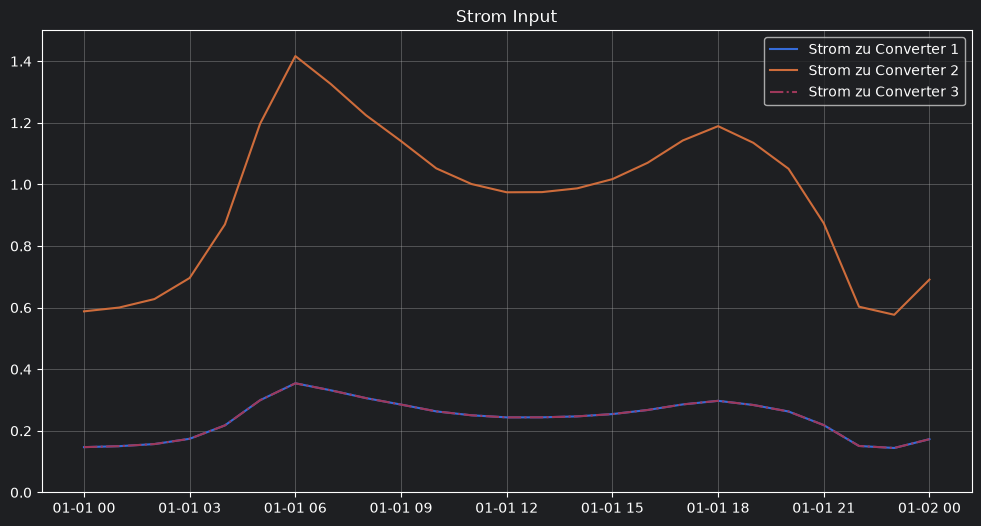

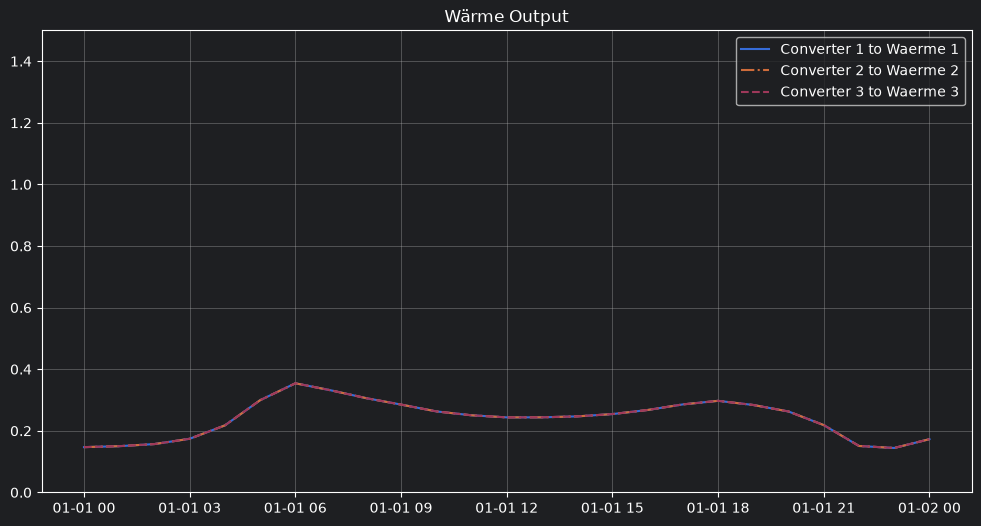

In [29]:

import matplotlib.pyplot as plt
import pandas as pd
from oemof import solph

fixture_path = pd.read_csv("input_data.csv", sep=",")
#print(fixture_path)

energysystem = solph.EnergySystem(
    timeindex=pd.date_range(
        start="2025-01-01",
        end="2025-01-02",
        freq="1h",
        inclusive="both",
    ),
    infer_last_interval=True
)

strom_bus = solph.buses.Bus(label="Strom")
waerme_bus_1 = solph.buses.Bus(label="Waerme 1")
waerme_bus_2 = solph.buses.Bus(label="Waerme 2")
waerme_bus_3 = solph.buses.Bus(label="Waerme 3")

quelle = solph.components.Source(
    label="Quelle",
    outputs={
        strom_bus: solph.Flow(
            variable_costs=100
        )
    }
)

pv = solph.components.Source(
    label="PV",
    outputs={
        strom_bus: solph.Flow(
            nominal_capacity=solph.Investment(
                ep_costs=100
            ),
            fix=fixture_path["pv"]
        )
    }
)

waerme_senke_1 = solph.components.Sink(
    label="Waerme Senke 1",
    inputs={
        waerme_bus_1: solph.Flow(
            nominal_capacity=1,
            fix=fixture_path["demand_th"]
        )
    }
)

waerme_senke_2 = solph.components.Sink(
    label="Waerme Senke 2",
    inputs={
        waerme_bus_2: solph.Flow(
            nominal_capacity=1,
            fix=fixture_path["demand_th"]
        )
    }
)

waerme_senke_3 = solph.components.Sink(
    label="Waerme Senke 3",
    inputs={
        waerme_bus_3: solph.Flow(
            nominal_capacity=1,
            fix=fixture_path["demand_th"]
        )
    }
)

converter_1 = solph.components.Converter(
    label="Converter 1",
    inputs={strom_bus: solph.Flow()},
    outputs={waerme_bus_1: solph.Flow(
        nominal_capacity=solph.Investment()
    )},
    conversion_factors={strom_bus: 0.5, waerme_bus_1: 0.5}
)

converter_2 = solph.components.Converter(
    label="Converter 2",
    inputs={strom_bus: solph.Flow()},
    outputs={waerme_bus_2: solph.Flow(
        nominal_capacity=solph.Investment()
    )},
    conversion_factors={strom_bus: 1, waerme_bus_2: 0.25}
)

converter_3 = solph.components.Converter(
    label="Converter 3",
    inputs={strom_bus: solph.Flow()},
    outputs={waerme_bus_3: solph.Flow(
        nominal_capacity=solph.Investment()
    )},
    conversion_factors={strom_bus: 1.25, waerme_bus_3: 1.25}
)

energysystem.add(
    quelle,
    pv,
    strom_bus,
    waerme_senke_1,
    waerme_senke_2,
    waerme_senke_3,
    waerme_bus_1,
    waerme_bus_2,
    waerme_bus_3,
    converter_1,
    converter_2,
    converter_3
)

#graph = energysystem.to_networkx()
#nx.draw(graph, with_labels=True, font_size=8)

model = solph.Model(
    energysystem=energysystem
)

model.solve(solver="gurobi", solve_kwargs={"tee": False})
results = solph.processing.results(model)

plt.figure(figsize=(12, 6))
plt.plot(
    results[(strom_bus, converter_1)]["sequences"],
    label="Strom zu Converter 1",
)

plt.plot(
    results[(strom_bus, converter_2)]["sequences"],
    label="Strom zu Converter 2",
)

plt.plot(
    results[(strom_bus, converter_3)]["sequences"],
    label="Strom zu Converter 3",
    linestyle="dashdot"
)
plt.title("Strom Input")
plt.ylim(0, 1.5)
plt.legend()
plt.grid()

plt.figure(figsize=(12, 6))
plt.plot(
    results[(converter_1, waerme_bus_1)]["sequences"],
    label="Converter 1 to Waerme 1",
)

plt.plot(
    results[(converter_2, waerme_bus_2)]["sequences"],
    label="Converter 2 to Waerme 2",
    linestyle="dashdot"
)

plt.plot(
    results[(converter_3, waerme_bus_3)]["sequences"],
    label="Converter 3 to Waerme 3",
    linestyle="dashed"
)
plt.title("Wärme Output")
plt.ylim(0, 1.5)
plt.legend()
plt.grid()

print("Coefficents")
print("----------------")
print("Converter 1:")
print(f"    Wärme: {converter_1.conversion_factors[waerme_bus_1][0]}")
print(f"    Strom: {converter_1.conversion_factors[strom_bus][0]}")
print("Converter 2:")
print(f"    Wärme: {converter_2.conversion_factors[waerme_bus_2][0]}")
print(f"    Strom: {converter_2.conversion_factors[strom_bus][0]}")
print("Converter 3:")
print(f"    Wärme: {converter_3.conversion_factors[waerme_bus_3][0]}")
print(f"    Strom: {converter_3.conversion_factors[strom_bus][0]}")
print()
print("Installed Powers")
print("----------------")
print(f"Converter 1: {results[(converter_1, waerme_bus_1)]['scalars']['total']} MW")
print(f"Converter 2: {results[(converter_2, waerme_bus_2)]['scalars']['total']} MW")
print(f"Converter 3: {results[(converter_3, waerme_bus_3)]['scalars']['total']} MW")


